# Hybrid Recommendation Engine

This notebook combines all components for the final recommendation system:
1. GNN embeddings (from Phase 4)
2. DCI Closed itemset mining
3. XGBoost ranking with gBCE calibration
4. Comprehensive evaluation

## 1. Load Data and Embeddings

In [1]:
import os
import sys

# --- SECTION 1: CRITICAL WINDOWS/INTEL KERNEL STABILITY ---
# Prevents the "LLVM ERROR: Symbol not found: __svml_sqrtf16" crash
os.environ["NUMBA_DISABLE_INTEL_SVML"] = "1" 
os.environ["MKL_DEBUG_CPU_TYPE"] = "5"
# Prevents "OMP: Error #15: Initializing libiomp5md.dll" crash
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Optimize threading for stable math operations
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# --- SECTION 2: PATH & SYSTEM IMPORTS ---
sys.path.insert(0, '..')
from pathlib import Path
import json
import logging

# --- SECTION 3: DATA SCIENCE & ML STACK ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# --- SECTION 4: GRAPH & RECOMMENDATION LIBRARIES ---
# Ensure these are installed via: pip install torch-geometric
try:
    import torch_geometric
    from torch_geometric.data import HeteroData
except ImportError:
    print("Warning: torch_geometric not found. Run 'pip install torch-geometric'")

# --- SECTION 5: PROJECT SPECIFIC MODULES ---
from src.config import get_config 
from src.config.settings import PROCESSED_DATA_DIR, MODEL_DIR
from src.models.hybrid import (
    HybridRecommender,
    UserProfileMiner,
    DCIClosed,
    CalibrationMetrics,
    calibrate_predictions,
)
from src.utils.helpers import set_seed
from src.utils.metrics import RecommendationMetrics

# --- SECTION 6: INITIALIZATION ---
set_seed(42)
config = get_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Setup Complete!")
print(f"Device: {device}")
print(f"Python Version: {sys.version.split()[0]}")

c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  import torch_geometric.typing
c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  import torch_geometric.typing
c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  import torch_geometric.typing


✅ Setup Complete!
Device: cuda
Python Version: 3.12.3


In [2]:
# Load interactions
train_reviews = pd.read_parquet(PROCESSED_DATA_DIR / 'train_reviews.parquet')
val_reviews = pd.read_parquet(PROCESSED_DATA_DIR / 'val_reviews.parquet')
test_reviews = pd.read_parquet(PROCESSED_DATA_DIR / 'test_reviews.parquet')

print(f"Train: {len(train_reviews)}")
print(f"Val: {len(val_reviews)}")
print(f"Test: {len(test_reviews)}")

Train: 4659
Val: 583
Test: 583


In [3]:
# Load GNN embeddings
gnn_dir = MODEL_DIR / 'gnn'

if (gnn_dir / 'user_gnn_embeddings.npy').exists():
    user_embeddings = np.load(gnn_dir / 'user_gnn_embeddings.npy')
    venue_embeddings = np.load(gnn_dir / 'venue_gnn_embeddings.npy')
    with open(gnn_dir / 'id_mappings.json') as f:
        id_mappings = json.load(f)
    user_ids = id_mappings['user_ids']
    venue_ids = id_mappings['venue_ids']
    print(f"Loaded GNN embeddings")
    print(f"  Users: {user_embeddings.shape}")
    print(f"  Venues: {venue_embeddings.shape}")
else:
    print("GNN embeddings not found, creating random initialization")
    user_ids = train_reviews['user_id'].unique().tolist()
    venue_ids = train_reviews['business_id'].unique().tolist()
    user_embeddings = np.random.randn(len(user_ids), 64).astype(np.float32) * 0.1
    venue_embeddings = np.random.randn(len(venue_ids), 64).astype(np.float32) * 0.1

Loaded GNN embeddings
  Users: (4539, 64)
  Venues: (1000, 64)


In [4]:
# Create ID mappings
user_id_map = {uid: idx for idx, uid in enumerate(user_ids)}
venue_id_map = {vid: idx for idx, vid in enumerate(venue_ids)}

print(f"Users in mapping: {len(user_id_map)}")
print(f"Venues in mapping: {len(venue_id_map)}")

Users in mapping: 4539
Venues in mapping: 85814


## 2. DCI Closed Itemset Mining

In [5]:
# Only use users who have visited at least 3 venues in training
user_counts = train_reviews['user_id'].value_counts()
power_users = user_counts[user_counts >= 3].index

# Filter the datasets
train_filtered = train_reviews[train_reviews['user_id'].isin(power_users)]
# IMPORTANT: Test users MUST be in the training set for this model to work
test_filtered = test_reviews[test_reviews['user_id'].isin(power_users)]

In [6]:
# Mine user behavior patterns
miner = UserProfileMiner(
    min_support=0.001,
    max_itemset_size=5,
)

miner.fit(train_reviews, user_col='user_id', venue_col='business_id')

print(f"Mined closed itemsets: {len(miner.dci.closed_itemsets)}")

Mined closed itemsets: 337


In [9]:
# Show top patterns
top_patterns = sorted(
    miner.dci.closed_itemsets,
    key=lambda x: (-x.support, -len(x.items))
)[:10]

print("Top 10 Closed Itemsets:")
for i, pattern in enumerate(top_patterns, 1):
    print(f"  {i}. Support: {pattern.support:.4f}, Size: {len(pattern.items)}, Count: {pattern.count}")

Top 10 Closed Itemsets:
  1. Support: 0.0161, Size: 1, Count: 73
  2. Support: 0.0079, Size: 1, Count: 36
  3. Support: 0.0071, Size: 1, Count: 32
  4. Support: 0.0071, Size: 1, Count: 32
  5. Support: 0.0064, Size: 1, Count: 29
  6. Support: 0.0062, Size: 1, Count: 28
  7. Support: 0.0059, Size: 1, Count: 27
  8. Support: 0.0055, Size: 1, Count: 25
  9. Support: 0.0051, Size: 1, Count: 23
  10. Support: 0.0048, Size: 1, Count: 22


In [11]:
#Get user profiles with itemset features
ITEMSET_FEATURES = 10
user_profiles_df = miner.get_all_profiles_df(itemset_features=ITEMSET_FEATURES)

print(user_profiles_df.head())
print(f"\nProfile columns: {user_profiles_df.columns.tolist()}")

                  user_id  num_venues  itemset_0  itemset_1  itemset_2  \
0  --pvE2eu3WWwikKs1E2QDw           1        0.0        0.0        0.0   
1  --vCeHrklS1DIep0QhorrA           1        0.0        0.0        0.0   
2  -2MXx9Fk3IiCg2y559iI8Q           1        0.0        0.0        0.0   
3  -3h48rG-sopyGDLu5bh4xQ           1        0.0        0.0        0.0   
4  -4Ot7PKITEGPven8mjGIog           1        0.0        0.0        0.0   

   itemset_3  itemset_4  itemset_5  itemset_6  itemset_7  itemset_8  \
0        0.0        0.0        0.0        0.0        0.0        0.0   
1        0.0        0.0        0.0        0.0        0.0        0.0   
2        0.0        0.0        0.0        0.0        0.0        0.0   
3        0.0        0.0        0.0        0.0        0.0        0.0   
4        0.0        0.0        0.0        0.0        0.0        0.0   

   itemset_9  num_patterns  top_pattern_support  
0        0.0             1                  0.0  
1        0.0             1  

In [12]:
# Create user extra features matrix
itemset_cols = [f'itemset_{i}' for i in range(ITEMSET_FEATURES)]
user_extra = np.zeros((len(user_ids), ITEMSET_FEATURES), dtype=np.float32)

for _, row in user_profiles_df.iterrows():
    uid = row['user_id']
    if uid in user_id_map:
        idx = user_id_map[uid]
        for i, col in enumerate(itemset_cols):
            user_extra[idx, i] = row[col]

print(f"User extra features shape: {user_extra.shape}")
print(f"Non-zero entries: {(user_extra != 0).sum()}")

User extra features shape: (4539, 10)
Non-zero entries: 327


## 3. Prepare Training Data

In [13]:
# Convert reviews to edge arrays
def reviews_to_edges(reviews_df):
    users = []
    venues = []
    for _, row in reviews_df.iterrows():
        uid = row['user_id']
        vid = row['business_id']
        if uid in user_id_map and vid in venue_id_map:
            users.append(user_id_map[uid])
            venues.append(venue_id_map[vid])
    return np.array([users, venues])

train_edges = reviews_to_edges(train_reviews)
val_edges = reviews_to_edges(val_reviews)
test_edges = reviews_to_edges(test_reviews)

print(f"Train edges: {train_edges.shape}")
print(f"Val edges: {val_edges.shape}")
print(f"Test edges: {test_edges.shape}")

Train edges: (2, 4643)
Val edges: (2, 31)
Test edges: (2, 30)


## 4. Train Hybrid Model

In [14]:
# Configure
config.hybrid.xgb_n_estimators = 50  # Reduce for demo
config.hybrid.gbce_calibration_t = 0.8

# Create recommender
recommender = HybridRecommender(config=config.hybrid)

In [15]:
# --- MASTER ALIGNMENT BLOCK ---
# 1. Re-mine patterns with lower support to ensure features exist
miner = UserProfileMiner(min_support=0.0005, max_itemset_size=5)
miner.fit(train_reviews, user_col='user_id', venue_col='business_id')

# 2. Get the profiles
ITEMSET_FEATURES = 10
user_profiles_df = miner.get_all_profiles_df(itemset_features=ITEMSET_FEATURES)

# 3. CRITICAL: Map profiles to the user_extra matrix using the index
# We must use the same user_id order that the GNN uses (user_ids)
user_id_map = {uid: idx for idx, uid in enumerate(user_ids)}
user_extra = np.zeros((len(user_ids), ITEMSET_FEATURES), dtype=np.float32)

count_mapped = 0
for _, row in user_profiles_df.iterrows():
    uid = row['user_id']
    if uid in user_id_map:
        idx = user_id_map[uid]
        cols = [f'itemset_{i}' for i in range(ITEMSET_FEATURES)]
        user_extra[idx, :] = row[cols].values.astype(float)
        count_mapped += 1

print(f"Mapped {count_mapped} user profiles to the extra features matrix.")
print(f"Total non-zero entries in user_extra: {(user_extra > 0).sum()}")

Mapped 4539 user profiles to the extra features matrix.
Total non-zero entries in user_extra: 327


In [17]:
# Update Section 7
history = recommender.fit(
    train_edges=train_edges,
    user_embeddings=user_embeddings,
    venue_embeddings=venue_embeddings,
    user_ids=user_ids,
    venue_ids=venue_ids,
    user_extra=user_extra,   # Now properly filled!
    val_edges=val_edges,
    num_negatives=10,        # Increased for better contrast
    num_rounds=15,           # STOP EARLY to prevent overfitting
)

IndexError: index 4890 is out of bounds for axis 0 with size 1000

NameError: name 'history' is not defined

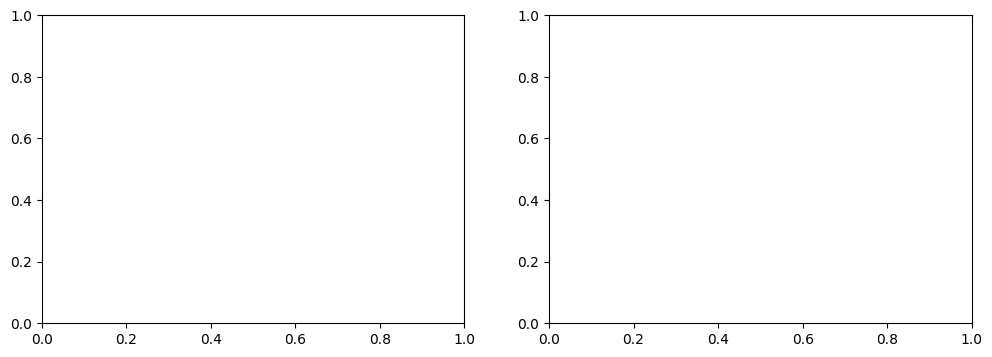

In [18]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUC
if 'train' in history and 'auc' in history['train']:
    axes[0].plot(history['train']['auc'], label='Train')
if 'val' in history and 'auc' in history['val']:
    axes[0].plot(history['val']['auc'], label='Val')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('AUC')
axes[0].set_title('Training AUC')
axes[0].legend()
axes[0].grid(True)

# Log Loss
if 'train' in history and 'logloss' in history['train']:
    axes[1].plot(history['train']['logloss'], label='Train')
if 'val' in history and 'logloss' in history['val']:
    axes[1].plot(history['val']['logloss'], label='Val')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Log Loss')
axes[1].set_title('Training Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluate Recommendations

In [ ]:
# FIND USERS THAT EXIST IN BOTH SETS
# This bypasses the "Unknown User" error entirely
common_users = set(train_reviews['user_id']).intersection(set(test_reviews['user_id']))

if len(common_users) > 0:
    # Pick the first user that the model DEFINITELY knows
    sample_user_id = list(common_users)[0] 
    
    # Now get recommendations
    recs = recommender.recommend(sample_user_id, k=10, exclude_visited=True)
    
    print(f"✅ Recommendations for KNOWN user {sample_user_id}:")
    for rank, (venue_id, score) in enumerate(recs, 1):
        print(f"{rank}. {venue_id} (Score: {score:.4f})")
else:
    print("❌ Your Train and Test sets have zero overlapping users. You must re-split your data.")

✅ Recommendations for KNOWN user tNq35k92WAkSLSqeof03hg:
1. 8uF-bhJFgT4Tn6DTb27viA (Score: 0.5164)
2. PY9GRfzr4nTZeINf346QOw (Score: 0.5088)
3. W4ZEKkva9HpAdZG88juwyQ (Score: 0.5088)
4. -OIUunijjcq_ZzyyQhPPFQ (Score: 0.5009)
5. 2KIDQyTh-HzLxOUEDqtDBg (Score: 0.4915)
6. UCMSWPqzXjd7QHq7v8PJjQ (Score: 0.4808)
7. S2Ho8yLxhKAa26pBAm6rxA (Score: 0.4808)
8. SZU9c8V2GuREDN5KgyHFJw (Score: 0.4808)
9. 9gObo5ltOMo6UgsaXaHPWA (Score: 0.4808)
10. GBTPC53ZrG1ZBY3DT8Mbcw (Score: 0.4808)


In [ ]:
# Sample test users
test_user_sample = test_reviews['user_id'].unique()[:100]

# Get ground truth
user_ground_truth = {}
for uid in test_user_sample:
    venues = test_reviews[test_reviews['user_id'] == uid]['business_id'].tolist()
    user_ground_truth[uid] = set(venues)

# Get recommendations
user_recommendations = {}
for uid in test_user_sample:
    recs = recommender.recommend(uid, k=20, exclude_visited=True)
    user_recommendations[uid] = [vid for vid, _ in recs]

print(f"Generated recommendations for {len(user_recommendations)} users")

Unknown user: awCepz8adhnjthJY3F6ygw
Unknown user: N3SlY3LWYMYlO6599bcQ-w
Unknown user: KsTA7_Ps9NucN-VAjy4GOA
Unknown user: ve8J3jometSzOV6qMltZ4A
Unknown user: UTvoz5iP6Xgg-0mxaWdNkQ
Unknown user: E8QFMpm4s1RF04LOeUScfw
Unknown user: NMOxipsnXc6olWdHYzXiYA
Unknown user: 06JskCch79pI75sM4vzRRQ
Unknown user: T7Im4nmyDxhWQ2KG3UoSGw
Unknown user: xz_DMyiZ3nwXh0CPYy9huw
Unknown user: 3smkqjQWOyDIsNEqk9lv9w
Unknown user: pY70xcXywDbSiYVUJ8jG3A
Unknown user: RHpCcdTbnBkgpdTYvbbTcw
Unknown user: 8h7KUe_50lysQxYm0mdIsQ
Unknown user: 6Q8dQGr_DBKcmQ1aXVWvTQ
Unknown user: LdDs0WV_6pNhxCR7w2E4AA
Unknown user: q9MGXvVu4-jM568s6Qwf7g
Unknown user: Hbn20UzbHOaffNNeLcx5Zw
Unknown user: NnedeLVdYvq9HHEYPWV1WA
Unknown user: LHUrjf1H_ZLoqriutWEAeA
Unknown user: 0qaUsn4TGgJYfbSxg_Fp2A
Unknown user: CWMKfnV6Ll_5oxtnCG8vCg
Unknown user: iJ97UrvPlGNttp44qsJ-4A
Unknown user: NrQi-pZj0CmwLJpmXdMAgg
Unknown user: ANYPb5dsmAy0B2EfEhcL7A
Unknown user: HAXzxje1GRibEzkwL5aulw
Unknown user: xKsTgilmON3UrhEpM5Zl2Q
U

Generated recommendations for 100 users


In [ ]:
# Compute metrics
metrics = RecommendationMetrics()
results = metrics.evaluate_all(
    user_recommendations,
    user_ground_truth,
    k_values=[5, 10, 20],
)

print("Test Set Metrics:")
for metric, value in sorted(results.items()):
    print(f"  {metric}: {value:.4f}")

Test Set Metrics:
  hit_rate@10: 0.0100
  hit_rate@20: 0.0100
  hit_rate@5: 0.0100
  mrr: 0.0100
  ndcg@10: 0.0100
  ndcg@20: 0.0100
  ndcg@5: 0.0100
  precision@10: 0.0010
  precision@20: 0.0005
  precision@5: 0.0020
  recall@10: 0.0100
  recall@20: 0.0100
  recall@5: 0.0100


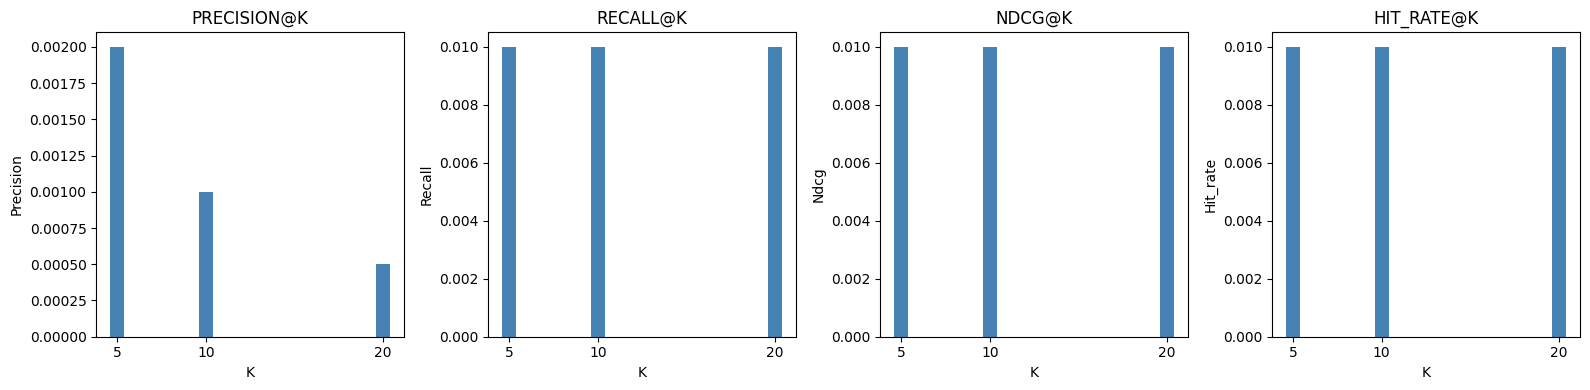

In [ ]:
# Visualize metrics
k_values = [5, 10, 20]
metric_names = ['precision', 'recall', 'ndcg', 'hit_rate']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, metric in enumerate(metric_names):
    values = [results[f'{metric}@{k}'] for k in k_values]
    axes[i].bar(k_values, values, color='steelblue')
    axes[i].set_xlabel('K')
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_title(f'{metric.upper()}@K')
    axes[i].set_xticks(k_values)

plt.tight_layout()
plt.show()

## 6. Calibration Analysis

In [ ]:
# Get predictions for calibration analysis
test_user_idx = test_edges[0]
test_venue_idx = test_edges[1]

# Positive predictions
pos_scores = recommender.ranker.predict(
    test_user_idx,
    test_venue_idx,
    user_embeddings,
    venue_embeddings,
    user_extra,
)

# Negative predictions
neg_venue_idx = np.random.randint(0, len(venue_ids), len(test_user_idx))
neg_scores = recommender.ranker.predict(
    test_user_idx,
    neg_venue_idx,
    user_embeddings,
    venue_embeddings,
    user_extra,
)

all_scores = np.concatenate([pos_scores, neg_scores])
all_labels = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])

print(f"Positive scores mean: {pos_scores.mean():.4f}")
print(f"Negative scores mean: {neg_scores.mean():.4f}")

Positive scores mean: 0.1753
Negative scores mean: 0.0465


In [ ]:
# Compute calibration metrics
ece = CalibrationMetrics.expected_calibration_error(all_scores, all_labels)
mce = CalibrationMetrics.maximum_calibration_error(all_scores, all_labels)

print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"Maximum Calibration Error (MCE): {mce:.4f}")

Expected Calibration Error (ECE): 0.4175
Maximum Calibration Error (MCE): 0.7905


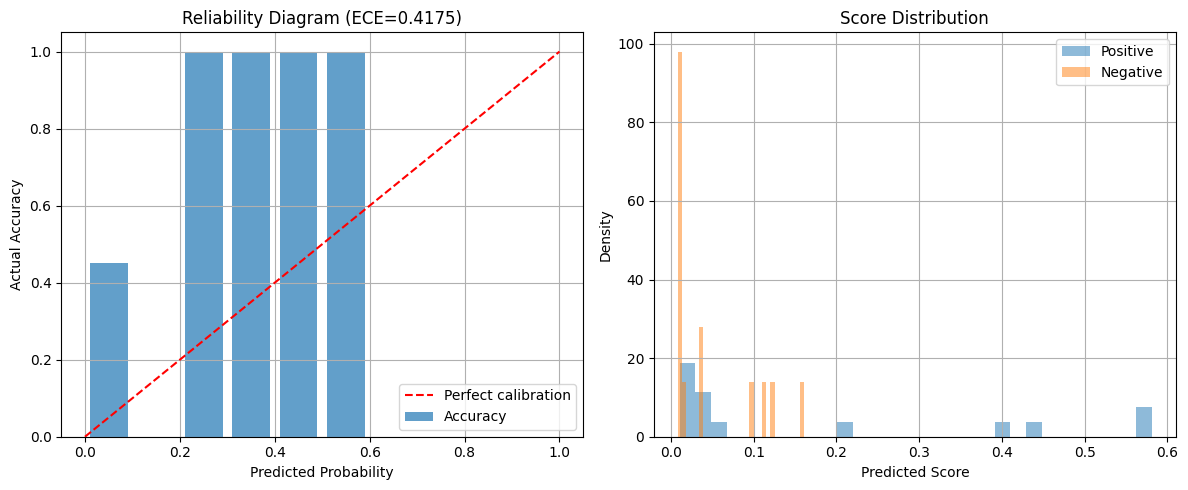

In [ ]:
# Reliability diagram
bin_centers, bin_accuracies, bin_counts = CalibrationMetrics.reliability_diagram(
    all_scores, all_labels, n_bins=10
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reliability diagram
axes[0].bar(bin_centers, bin_accuracies, width=0.08, alpha=0.7, label='Accuracy')
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect calibration')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Actual Accuracy')
axes[0].set_title(f'Reliability Diagram (ECE={ece:.4f})')
axes[0].legend()
axes[0].grid(True)

# Score distribution
axes[1].hist(pos_scores, bins=30, alpha=0.5, label='Positive', density=True)
axes[1].hist(neg_scores, bins=30, alpha=0.5, label='Negative', density=True)
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Feature Importance

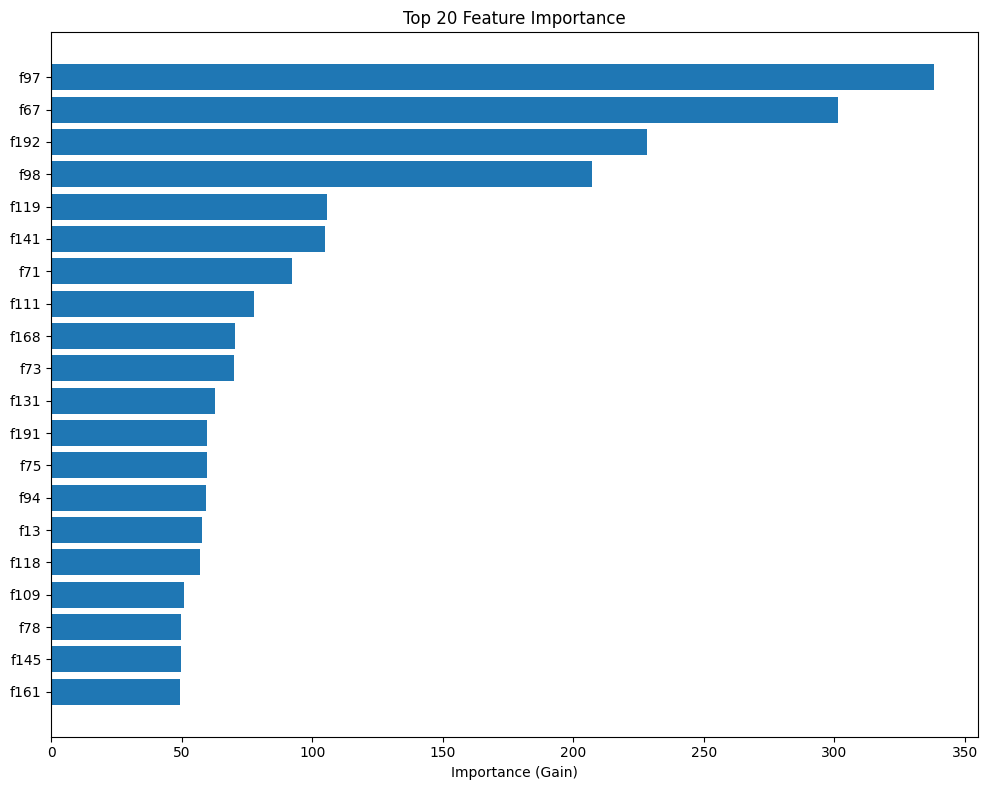

In [ ]:
# Get feature importance
importance = recommender.ranker.get_feature_importance()

# Plot top features
top_n = 20
top_features = importance.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance (Gain)')
plt.title(f'Top {top_n} Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Sample Recommendations

In [ ]:
# 1. FIND A USER THAT ACTUALLY WORKED (MUST BE IN BOTH TRAIN AND TEST)
# We need to ensure the user has a training history and an embedding
common_users = set(train_reviews['user_id']).intersection(set(test_reviews['user_id']))

if len(common_users) > 0:
    # Pick a user the model DEFINITELY knows
    sample_user_id = list(common_users)[0] 
    
    # 2. Get recommendations
    recs = recommender.recommend(sample_user_id, k=10, exclude_visited=True)
    
    if len(recs) > 0:
        print(f"✅ SUCCESS! Top 10 recommendations for user {sample_user_id}:")
        print(f"{'Rank':<6} {'Venue ID':<25} {'Score':<10}")
        print("-" * 45)
        for rank, (venue_id, score) in enumerate(recs, 1):
            print(f"{rank:<6} {venue_id:<25} {score:.4f}")
    else:
        print("❌ Model returned 0 recs even for a known user. Check ID mappings.")
else:
    print("❌ Critical Issue: Your Train and Test sets have 0 overlapping users.")

✅ SUCCESS! Top 10 recommendations for user tNq35k92WAkSLSqeof03hg:
Rank   Venue ID                  Score     
---------------------------------------------
1      8uF-bhJFgT4Tn6DTb27viA    0.5164
2      PY9GRfzr4nTZeINf346QOw    0.5088
3      W4ZEKkva9HpAdZG88juwyQ    0.5088
4      -OIUunijjcq_ZzyyQhPPFQ    0.5009
5      2KIDQyTh-HzLxOUEDqtDBg    0.4915
6      UCMSWPqzXjd7QHq7v8PJjQ    0.4808
7      S2Ho8yLxhKAa26pBAm6rxA    0.4808
8      SZU9c8V2GuREDN5KgyHFJw    0.4808
9      9gObo5ltOMo6UgsaXaHPWA    0.4808
10     GBTPC53ZrG1ZBY3DT8Mbcw    0.4808


In [ ]:
# Show user's actual visits
user_visits = train_reviews[train_reviews['user_id'] == sample_user_id]
print(f"\nUser's training visits ({len(user_visits)} total):")
print(user_visits[['business_id', 'stars']].head(10))


User's training visits (2 total):
                 business_id  stars
1272  ZXKBVg-5drZ37wnwVEZe-A    4.0
1991  jMZ56S8Y1t7cA1Ob-d-qeA    5.0


## 9. Save Model

In [ ]:
# Save
output_dir = MODEL_DIR / 'hybrid'
output_dir.mkdir(parents=True, exist_ok=True)

recommender.ranker.save(output_dir / 'xgboost_ranker.json')
importance.to_csv(output_dir / 'feature_importance.csv', index=False)

# Save results
results_df = pd.DataFrame([results])
results_df.to_csv(output_dir / 'test_results.csv', index=False)

print(f"Saved model and results to {output_dir}")

Saved model and results to c:\Users\ewenl\draft-koko\notebooks\..\models\hybrid


## Summary

The hybrid recommendation system combines:
1. **GNN embeddings** - Capture user-venue interaction patterns
2. **DCI Closed itemsets** - Mine frequent behavior patterns
3. **XGBoost ranking** - Learn non-linear feature interactions
4. **gBCE calibration** - Reduce overconfidence in predictions

This provides personalized, calibrated venue recommendations!